# Bayesian Neural Networks (BNNs)

## 1. Why Bayesian neural networks?

Standard neural networks often output a **single best-guess prediction** (a point estimate), usually obtained by minimizing a loss like MSE or cross-entropy.

In many real settings we want **uncertainty-aware predictions**, for example:

- Medical decision support: “How sure are we?”
- Autonomous systems: “Should we hand over control?”
- Active learning: “Which point would be most informative to label next?”
- Out-of-distribution (OOD) detection: “Have we seen anything like this before?”
- Model debugging and calibration: “Are probabilities meaningful?”

### Two common types of uncertainty

- **Aleatoric uncertainty**: inherent noise in the data generation process (e.g., measurement noise).
- **Epistemic uncertainty**: uncertainty due to limited data / knowledge (model uncertainty).  
  Epistemic uncertainty should **decrease** with more data, and often **increase** far away from the training set.

BNNs target epistemic uncertainty by putting a **probability distribution over weights**.


## 2. The Bayesian view of a neural network

Let a neural network have weights and biases collected into a vector $w$.

### Ingredients

- **Prior** over parameters:  
  $$
  p(w)
  $$
  Encodes beliefs before seeing data (e.g. weights should be near 0).

- **Likelihood** (data model): for a dataset $D=\{(x_i,y_i)\}_{i=1}^N$,
  $$
  p(D \mid w)=\prod_{i=1}^N p(y_i \mid x_i, w)
  $$

- **Posterior** via Bayes’ rule:
  $$
  p(w \mid D) = \frac{p(D \mid w)\,p(w)}{p(D)}
  $$
  where $p(D)=\int p(D\mid w)p(w)\,dw$ is the *evidence* (or marginal likelihood).

### Predictions

For a new input $x^*$, the Bayesian predictive distribution averages over plausible weights:

$$
p(y^* \mid x^*, D) = \int p(y^* \mid x^*, w)\,p(w \mid D)\,dw
$$

This integral is the source of “Bayesian averaging” and (when done well) better-calibrated uncertainty.


## 3. Why exact inference is hard in neural networks

For most modern neural networks:

- The posterior $p(w\mid D)$ is **high-dimensional** and **non-convex**.
- The evidence $p(D)=\int p(D\mid w)p(w)\,dw$ is **intractable**.
- The predictive integral is also intractable.

Therefore, we use **approximate Bayesian inference**.


## 4. Approximate inference options (high-level)

Common approaches to approximate $p(w\mid D)$ or approximate predictive uncertainty:

1. **Variational inference (VI)**: fit a tractable distribution $q_\theta(w)$ to approximate the posterior.
2. **MCMC** (e.g., HMC, SG-MCMC): asymptotically exact but often expensive for large NNs.
3. **Laplace approximation**: approximate posterior locally around MAP by a Gaussian.
4. **Deep ensembles**: train multiple deterministic nets; can work surprisingly well.
5. **MC Dropout**: interpret dropout as approximate Bayesian inference (quick and popular).

In this notebook we focus on **variational inference** and show **MC dropout** as a baseline.


## 5. Variational inference and the ELBO

We choose a family of distributions $q_\theta(w)$ (e.g., a factorized Gaussian) and fit it to be close to the true posterior.

A common objective is to minimize the KL divergence:

$$
\theta^* = \arg\min_\theta \mathrm{KL}\big(q_\theta(w) \,\|\, p(w\mid D)\big)
$$

This is equivalent to maximizing the **Evidence Lower Bound (ELBO)**:

$$
\mathcal{L}(\theta)
= \mathbb{E}_{q_\theta(w)}[\log p(D\mid w)]
- \mathrm{KL}\big(q_\theta(w) \,\|\, p(w)\big)
$$

Interpretation:

- $\mathbb{E}_{q}[\log p(D\mid w)]$: **data fit** term (expected log-likelihood)
- $\mathrm{KL}(q\|p)$: **complexity penalty** encouraging $q$ to stay near the prior

Maximizing ELBO balances fitting the data and staying close to the prior.


## 6. Bayes by Backprop (mean-field VI) in a nutshell

A simple and popular choice is a **mean-field Gaussian posterior**:

$$
q_\theta(w) = \prod_{j} \mathcal{N}(w_j \mid \mu_j, \sigma_j^2)
$$

We learn $\mu$ and $\sigma$. In practice we parameterize $\sigma$ via an unconstrained variable $\rho$:

$$
\sigma = \mathrm{softplus}(\rho) = \log(1+\exp(\rho))
$$

### Reparameterization trick

To backpropagate through sampling, write:

$$
w = \mu + \sigma \odot \varepsilon,\quad \varepsilon \sim \mathcal{N}(0,I)
$$

Now randomness is isolated in $\varepsilon$, and gradients flow through $\mu,\sigma$.

### Closed-form KL (Gaussian vs Gaussian)

If $q=\mathcal{N}(\mu_q,\sigma_q^2)$ and $p=\mathcal{N}(\mu_p,\sigma_p^2)$:

$$
\mathrm{KL}(q\|p) =
\log\frac{\sigma_p}{\sigma_q}
+ \frac{\sigma_q^2 + (\mu_q-\mu_p)^2}{2\sigma_p^2}
- \frac{1}{2}
$$

We sum this over all weights (assuming independence).


## 7. Practical notes (what can go wrong)

1. **Scaling the KL term in minibatch training**  
   The ELBO is defined over the whole dataset. With minibatches we typically scale the KL term by $\frac{\text{batch\_size}}{N}$ (or equivalently distribute KL across batches).

2. **Choice of prior matters**  
   A too-tight prior can underfit; a too-wide prior can lead to overfitting and unstable training.

3. **VI often underestimates uncertainty**  
   Minimizing $\mathrm{KL}(q\|p)$ (the “exclusive KL”) tends to favor “mode-seeking” approximations.

4. **Number of MC samples**  
   Training often uses 1 sample per minibatch for speed. Prediction typically uses many samples.

5. **Regression likelihood**  
   For regression you can model observation noise $\sigma_y$ (aleatoric). In this notebook we keep it simple and treat $\sigma_y$ as fixed in one demo.


In [8]:
# If you run this on a GPU machine, PyTorch will use it automatically.
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

def set_seed(seed: int = 0) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "mps"
set_seed(0)
print("Device:", device)


Device: mps


# Demo A: Regression with epistemic uncertainty

We generate a 1D regression dataset:

$$
y = \sin(x) + \epsilon,\quad \epsilon \sim \mathcal{N}(0, \sigma_\text{noise}^2)
$$

We train on $x \in [-3,3]$ and evaluate on a wider range $x \in [-6,6]$.

A good BNN should show **larger uncertainty** outside the training region.


In [9]:
# Generate toy data
set_seed(1)

N_train = 128
noise_std = 0.3

x_train = np.random.uniform(-3.0, 3.0, size=(N_train, 1)).astype(np.float32)
y_train = np.sin(x_train) + noise_std * np.random.randn(N_train, 1).astype(np.float32)

# Dense grid for visualization (includes OOD regions)
x_grid = np.linspace(-6.0, 6.0, 400, dtype=np.float32).reshape(-1, 1)
y_true = np.sin(x_grid)

# Torch tensors
X_train = torch.from_numpy(x_train).to(device)
Y_train = torch.from_numpy(y_train).to(device)
X_grid = torch.from_numpy(x_grid).to(device)
Y_true = torch.from_numpy(y_true).to(device)

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=64,
    shuffle=True,
)

print("Train X range:", x_train.min(), x_train.max())


Train X range: -2.9993138 2.983937


## A1. Baseline: deterministic neural network (no Bayesian treatment)

A deterministic network learns a single point estimate $\hat{w}$.  
It can fit the data, but it **does not naturally represent epistemic uncertainty**.

(You can still bolt on uncertainty estimates via ensembling, quantile regression, etc., but that's beyond this baseline.)


[Deterministic] epoch= 300  mse=0.0788
[Deterministic] epoch= 600  mse=0.0847
[Deterministic] epoch= 900  mse=0.0783
[Deterministic] epoch=1200  mse=0.0860
[Deterministic] epoch=1500  mse=0.0857


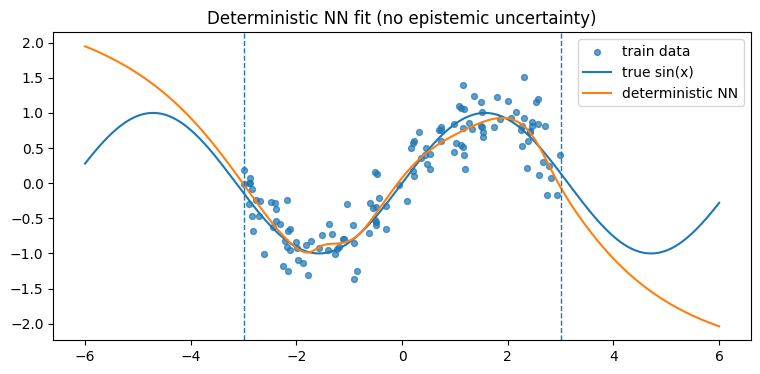

In [10]:
class DeterministicMLP(nn.Module):
    def __init__(self, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x)

det_model = DeterministicMLP(hidden=64).to(device)
opt = torch.optim.Adam(det_model.parameters(), lr=1e-3)

epochs = 1500

det_model.train()
for epoch in range(1, epochs + 1):
    for xb, yb in train_loader:
        pred = det_model(xb)
        loss = F.mse_loss(pred, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
    if epoch % 300 == 0:
        print(f"[Deterministic] epoch={epoch:4d}  mse={loss.item():.4f}")

det_model.eval()
with torch.no_grad():
    y_det = det_model(X_grid).cpu().numpy()

plt.figure(figsize=(9, 4))
plt.scatter(x_train, y_train, s=18, alpha=0.7, label="train data")
plt.plot(x_grid, y_true, label="true sin(x)")
plt.plot(x_grid, y_det, label="deterministic NN")
plt.axvline(-3, linestyle="--", linewidth=1)
plt.axvline( 3, linestyle="--", linewidth=1)
plt.title("Deterministic NN fit (no epistemic uncertainty)")
plt.legend()
plt.show()


## A2. Bayesian neural network via variational inference (Bayes by Backprop)

We implement a variational linear layer:

- Posterior over each weight: $q(w_{ij})=\mathcal{N}(\mu_{ij}, \sigma_{ij}^2)$
- Prior over weights: $p(w_{ij})=\mathcal{N}(0, \sigma_\text{prior}^2)$

Training objective (minimize):

$$
\text{loss} = \underbrace{\frac{1}{B}\sum_{i=1}^B -\log p(y_i\mid x_i,w)}_{\text{negative log-likelihood}}
\;+\;
\underbrace{\frac{\beta}{N}\mathrm{KL}(q(w)\|p(w))}_{\text{complexity penalty}}
$$

- $B$ = batch size, $N$ = dataset size  
- $\beta$ can be used for **KL annealing** (warm-up) or “$\beta$-VI”.


[BNN] epoch= 400  nll=0.8209  kl/N=59.9815  beta=0.80
[BNN] epoch= 800  nll=1.5326  kl/N=33.8441  beta=1.00
[BNN] epoch=1200  nll=1.4781  kl/N=19.7574  beta=1.00
[BNN] epoch=1600  nll=0.5702  kl/N=11.9408  beta=1.00
[BNN] epoch=2000  nll=0.7107  kl/N=7.6660  beta=1.00


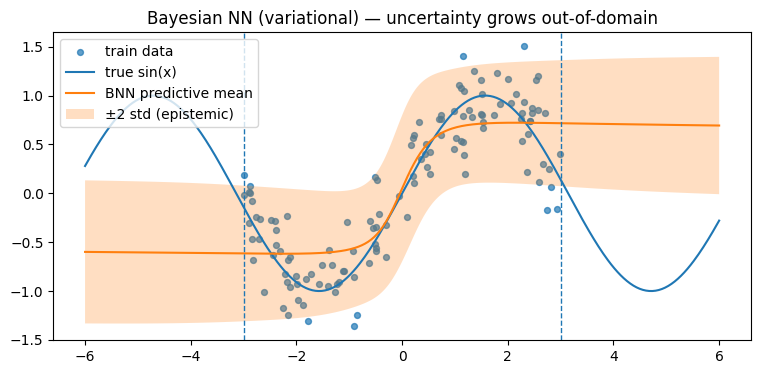

In [11]:
def softplus(x: torch.Tensor) -> torch.Tensor:
    return torch.log1p(torch.exp(-torch.abs(x))) + torch.maximum(x, torch.zeros_like(x))

class VariationalLinear(nn.Module):
    '''
    Mean-field variational Bayes linear layer:
      q(W) = Normal(mu_W, sigma_W^2),  q(b) = Normal(mu_b, sigma_b^2)
    Prior:
      p(W) = Normal(0, prior_sigma^2), p(b) = Normal(0, prior_sigma^2)
    '''
    def __init__(self, in_features: int, out_features: int, prior_sigma: float = 1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.prior_sigma = prior_sigma

        # Posterior parameters
        self.mu_W = nn.Parameter(torch.empty(out_features, in_features).normal_(0, 0.1))
        self.rho_W = nn.Parameter(torch.empty(out_features, in_features).normal_(-3.0, 0.1))

        self.mu_b = nn.Parameter(torch.empty(out_features).normal_(0, 0.1))
        self.rho_b = nn.Parameter(torch.empty(out_features).normal_(-3.0, 0.1))

    def sigma_W(self) -> torch.Tensor:
        return softplus(self.rho_W)

    def sigma_b(self) -> torch.Tensor:
        return softplus(self.rho_b)

    def sample_params(self):
        eps_W = torch.randn_like(self.mu_W)
        eps_b = torch.randn_like(self.mu_b)
        W = self.mu_W + self.sigma_W() * eps_W
        b = self.mu_b + self.sigma_b() * eps_b
        return W, b

    def kl_divergence(self) -> torch.Tensor:
        # KL(q||p) for factorized Gaussians, summed over all parameters
        prior_var = self.prior_sigma ** 2

        sigma_W = self.sigma_W()
        sigma_b = self.sigma_b()

        # For each parameter:
        # KL(N(mu, sigma^2) || N(0, prior_sigma^2)) =
        #   log(prior_sigma/sigma) + (sigma^2 + mu^2)/(2*prior_sigma^2) - 1/2
        kl_W = (
            torch.log(self.prior_sigma / sigma_W)
            + (sigma_W**2 + self.mu_W**2) / (2.0 * prior_var)
            - 0.5
        ).sum()

        kl_b = (
            torch.log(self.prior_sigma / sigma_b)
            + (sigma_b**2 + self.mu_b**2) / (2.0 * prior_var)
            - 0.5
        ).sum()

        return kl_W + kl_b

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        W, b = self.sample_params()
        return F.linear(x, W, b)


class BayesianMLP(nn.Module):
    def __init__(self, hidden: int = 64, prior_sigma: float = 1.0):
        super().__init__()
        self.l1 = VariationalLinear(1, hidden, prior_sigma=prior_sigma)
        self.l2 = VariationalLinear(hidden, hidden, prior_sigma=prior_sigma)
        self.l3 = VariationalLinear(hidden, 1, prior_sigma=prior_sigma)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.tanh(self.l1(x))
        x = torch.tanh(self.l2(x))
        x = self.l3(x)
        return x

    def kl_loss(self) -> torch.Tensor:
        return self.l1.kl_divergence() + self.l2.kl_divergence() + self.l3.kl_divergence()


def gaussian_nll(y: torch.Tensor, mean: torch.Tensor, obs_sigma: float) -> torch.Tensor:
    """Mean negative log-likelihood under N(mean, obs_sigma^2)."""
    var = obs_sigma ** 2
    return 0.5 * (math.log(2 * math.pi * var) + ((y - mean) ** 2) / var).mean()


# Train BNN
bnn = BayesianMLP(hidden=64, prior_sigma=1.0).to(device)
opt = torch.optim.Adam(bnn.parameters(), lr=1e-3)

epochs = 2000
obs_sigma = noise_std  # assume we know observation noise here for simplicity
N = len(X_train)

bnn.train()
for epoch in range(1, epochs + 1):
    # KL warm-up (annealing): slowly increase beta from 0 to 1
    beta = min(1.0, epoch / 500.0)

    for xb, yb in train_loader:
        pred = bnn(xb)               # samples weights internally
        nll = gaussian_nll(yb, pred, obs_sigma=obs_sigma)
        kl = bnn.kl_loss()

        loss = nll + beta * kl / N

        opt.zero_grad()
        loss.backward()
        opt.step()

    if epoch % 400 == 0:
        print(f"[BNN] epoch={epoch:4d}  nll={nll.item():.4f}  kl/N={(kl/N).item():.4f}  beta={beta:.2f}")

# Monte Carlo prediction
bnn.eval()
S = 200  # number of weight samples for prediction
with torch.no_grad():
    preds = []
    for _ in range(S):
        preds.append(bnn(X_grid).cpu().numpy())
    preds = np.stack(preds, axis=0)  # [S, n_grid, 1]

pred_mean = preds.mean(axis=0).squeeze(-1)
pred_std  = preds.std(axis=0).squeeze(-1)

plt.figure(figsize=(9, 4))
plt.scatter(x_train, y_train, s=18, alpha=0.7, label="train data")
plt.plot(x_grid, y_true, label="true sin(x)")
plt.plot(x_grid, pred_mean, label="BNN predictive mean")

# 95% interval (approx.)
upper = pred_mean + 2.0 * pred_std
lower = pred_mean - 2.0 * pred_std
plt.fill_between(x_grid.squeeze(), lower, upper, alpha=0.25, label="±2 std (epistemic)")

plt.axvline(-3, linestyle="--", linewidth=1)
plt.axvline( 3, linestyle="--", linewidth=1)
plt.title("Bayesian NN (variational) — uncertainty grows out-of-domain")
plt.legend()
plt.show()


## A3. Quick baseline: Monte Carlo (MC) Dropout

MC Dropout is a pragmatic technique:

- Train a standard net **with dropout**.
- At prediction time, keep dropout **ON** and sample multiple forward passes.
- The variability across samples acts as an approximate epistemic uncertainty estimate.

It is not a “full BNN”, but it is widely used because it is simple and often effective.


[Dropout] epoch= 300  mse=0.1020
[Dropout] epoch= 600  mse=0.0743
[Dropout] epoch= 900  mse=0.0872
[Dropout] epoch=1200  mse=0.0717
[Dropout] epoch=1500  mse=0.0743


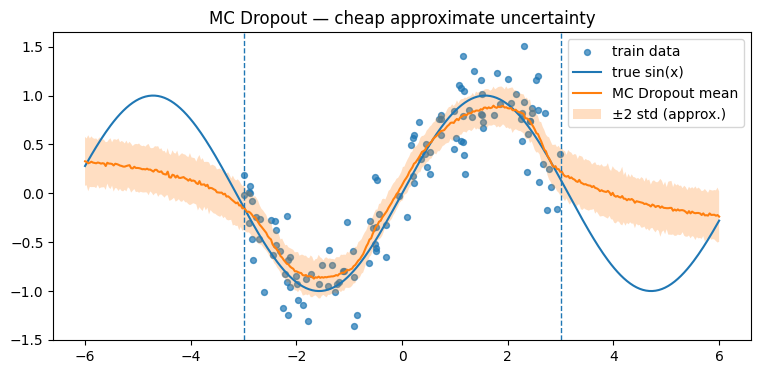

In [12]:
class DropoutMLP(nn.Module):
    def __init__(self, hidden: int = 64, p_drop: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, 1)
        self.drop = nn.Dropout(p_drop)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = self.drop(x)
        x = torch.tanh(self.fc2(x))
        x = self.drop(x)
        x = self.fc3(x)
        return x

drop_model = DropoutMLP(hidden=64, p_drop=0.1).to(device)
opt = torch.optim.Adam(drop_model.parameters(), lr=1e-3)

epochs = 1500
drop_model.train()
for epoch in range(1, epochs + 1):
    for xb, yb in train_loader:
        pred = drop_model(xb)
        loss = F.mse_loss(pred, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
    if epoch % 300 == 0:
        print(f"[Dropout] epoch={epoch:4d}  mse={loss.item():.4f}")

# MC prediction: keep dropout active by using train() during sampling,
# but disable gradients.
S = 200
drop_model.train()
with torch.no_grad():
    preds = []
    for _ in range(S):
        preds.append(drop_model(X_grid).cpu().numpy())
    preds = np.stack(preds, axis=0)

pred_mean = preds.mean(axis=0).squeeze(-1)
pred_std  = preds.std(axis=0).squeeze(-1)

plt.figure(figsize=(9, 4))
plt.scatter(x_train, y_train, s=18, alpha=0.7, label="train data")
plt.plot(x_grid, y_true, label="true sin(x)")
plt.plot(x_grid, pred_mean, label="MC Dropout mean")
plt.fill_between(
    x_grid.squeeze(),
    pred_mean - 2.0 * pred_std,
    pred_mean + 2.0 * pred_std,
    alpha=0.25,
    label="±2 std (approx.)",
)
plt.axvline(-3, linestyle="--", linewidth=1)
plt.axvline( 3, linestyle="--", linewidth=1)
plt.title("MC Dropout — cheap approximate uncertainty")
plt.legend()
plt.show()


## A4. Dropout as regularisation — preventing overfitting

Standard dropout randomly zeroes activations during training with probability $p$.
This acts as an **implicit ensemble / regulariser**: each forward pass uses a different
random sub-network, which reduces co-adaptation of neurons and shrinks the gap between
train and test error.

Below we train a deliberately **large** MLP (hidden=256, 4 hidden layers) that can easily
overfit our small 128-point dataset. We compare training **with** and **without** dropout
(p=0.3) and plot the train / test MSE curves.

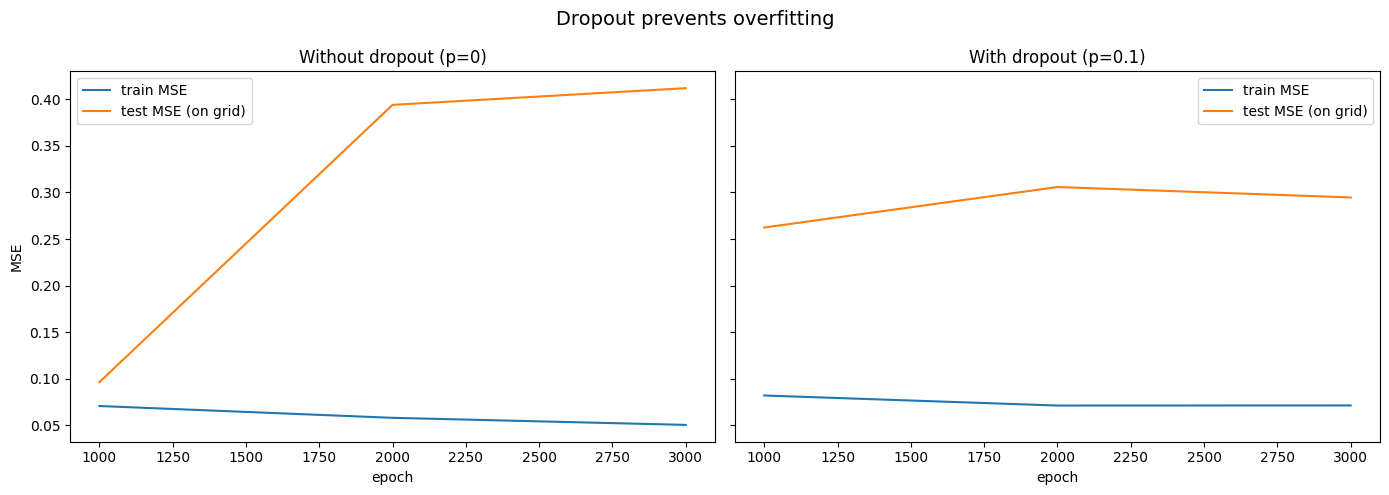

In [24]:
class LargeMLP(nn.Module):
    """4-hidden-layer MLP (hidden=256) — large enough to overfit 128 points."""
    def __init__(self, hidden: int = 256, p_drop: float = 0.0):
        super().__init__()
        self.use_dropout = p_drop > 0
        self.fc1 = nn.Linear(1, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, hidden)
        self.fc4 = nn.Linear(hidden, hidden)
        self.fc5 = nn.Linear(hidden, 1)
        if self.use_dropout:
            self.drop = nn.Dropout(p_drop)

    def forward(self, x):
        for fc in [self.fc1, self.fc2, self.fc3, self.fc4]:
            x = torch.tanh(fc(x))
            if self.use_dropout:
                x = self.drop(x)
        return self.fc5(x)


def train_and_record(model, train_loader, X_grid, Y_true, epochs=3000, log_every=50, lr=1e-3):
    """Train *model* and return per-epoch train/test MSE lists."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    train_mse_hist, test_mse_hist = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
            n_batches += 1

        if epoch % log_every == 0:
            train_mse_hist.append(epoch_loss / n_batches)
            model.eval()
            with torch.no_grad():
                test_mse = F.mse_loss(model(X_grid), Y_true).item()
            test_mse_hist.append(test_mse)

    return train_mse_hist, test_mse_hist


set_seed(1)
epochs, log_every = 3000, 1000

no_drop_model = LargeMLP(hidden=256, p_drop=0.0).to(device)
drop_reg_model = LargeMLP(hidden=256, p_drop=0.2).to(device)

train_no, test_no = train_and_record(no_drop_model, train_loader, X_grid, Y_true,
                                     epochs=epochs, log_every=log_every)
train_dr, test_dr = train_and_record(drop_reg_model, train_loader, X_grid, Y_true,
                                     epochs=epochs, log_every=log_every)

x_epochs = list(range(log_every, epochs + 1, log_every))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].set_title("Without dropout (p=0)")
axes[0].plot(x_epochs, train_no, label="train MSE")
axes[0].plot(x_epochs, test_no, label="test MSE (on grid)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].set_title("With dropout (p=0.1)")
axes[1].plot(x_epochs, train_dr, label="train MSE")
axes[1].plot(x_epochs, test_dr, label="test MSE (on grid)")
axes[1].set_xlabel("epoch")
axes[1].legend()

fig.suptitle("Dropout prevents overfitting", fontsize=14)
plt.tight_layout()
plt.show()

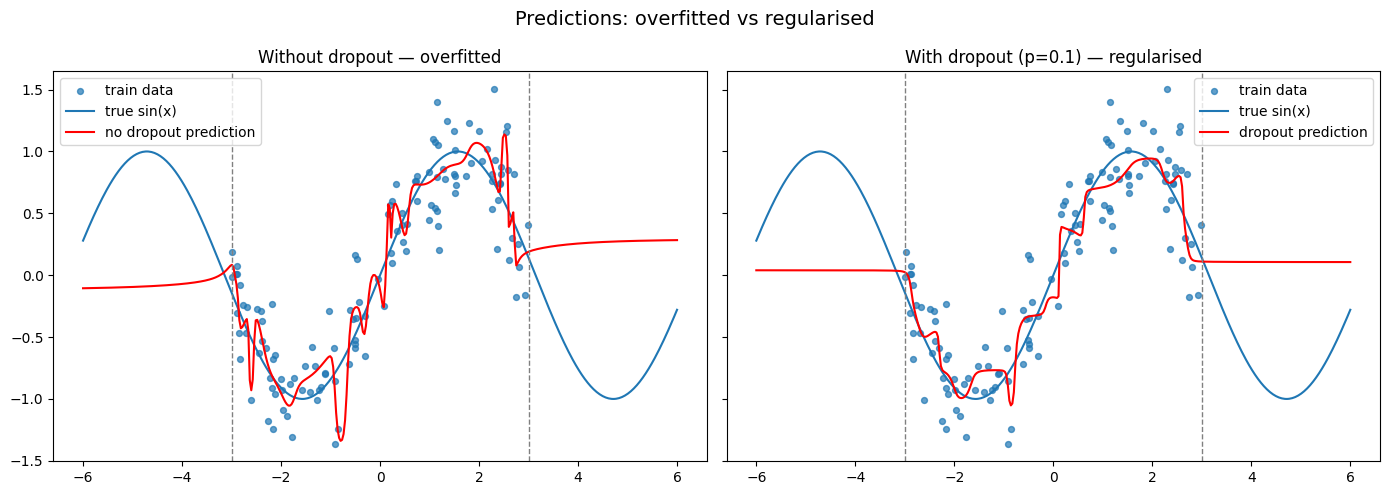

In [26]:
no_drop_model.eval()
drop_reg_model.eval()

with torch.no_grad():
    y_no_drop = no_drop_model(X_grid).cpu().numpy()
    y_drop = drop_reg_model(X_grid).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(x_train, y_train, s=18, alpha=0.7, label="train data")
axes[0].plot(x_grid, y_true, label="true sin(x)")
axes[0].plot(x_grid, y_no_drop, label="no dropout prediction", color="red")
axes[0].axvline(-3, ls="--", lw=1, color="grey")
axes[0].axvline( 3, ls="--", lw=1, color="grey")
axes[0].set_title("Without dropout — overfitted")
axes[0].legend()

axes[1].scatter(x_train, y_train, s=18, alpha=0.7, label="train data")
axes[1].plot(x_grid, y_true, label="true sin(x)")
axes[1].plot(x_grid, y_drop, label="dropout prediction", color="red")
axes[1].axvline(-3, ls="--", lw=1, color="grey")
axes[1].axvline( 3, ls="--", lw=1, color="grey")
axes[1].set_title("With dropout (p=0.1) — regularised")
axes[1].legend()

fig.suptitle("Predictions: overfitted vs regularised", fontsize=14)
plt.tight_layout()
plt.show()

## A5. Gaussian (multiplicative) dropout vs. Bernoulli dropout

**Bernoulli dropout** masks each activation with $\text{Bernoulli}(1-p)$ and scales
survivors by $\frac{1}{1-p}$.

**Gaussian dropout** multiplies each activation by noise drawn from
$\mathcal{N}(1, \alpha)$ where $\alpha = p\,(1-p)$.
Equivalently, the effective weight becomes
$W \sim \mathcal{N}\!\bigl(\mu,\;\alpha\,\mu^2\bigr)$
with $\alpha = (1-p)\,p$.

Both variants can be used for **MC Dropout** at test time to obtain cheap
approximate uncertainty estimates. Below we compare their uncertainty bands
on the same 1-D regression task.

[ Bernoulli] epoch= 500  mse=0.0926
[ Bernoulli] epoch=1000  mse=0.0882
[ Bernoulli] epoch=1500  mse=0.0793
[  Gaussian] epoch= 500  mse=0.1101
[  Gaussian] epoch=1000  mse=0.0836
[  Gaussian] epoch=1500  mse=0.0934


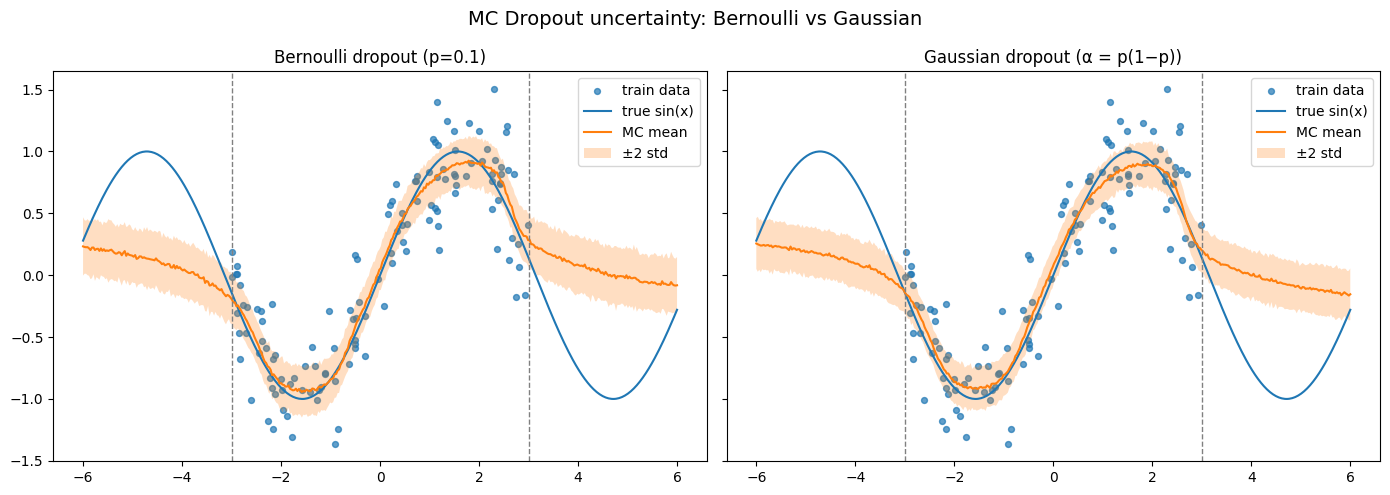

In [14]:
class GaussianDropout(nn.Module):
    """Multiplicative Gaussian dropout: x * N(1, alpha) during training.

    alpha = p * (1 - p), matching the variance of scaled Bernoulli dropout
    when the drop probability is p.
    """
    def __init__(self, p: float = 0.1):
        super().__init__()
        self.alpha = p * (1.0 - p)

    def forward(self, x):
        if self.training and self.alpha > 0:
            noise = torch.randn_like(x) * (self.alpha ** 0.5) + 1.0
            return x * noise
        return x


class GaussianDropoutMLP(nn.Module):
    def __init__(self, hidden: int = 64, p: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, 1)
        self.drop = GaussianDropout(p)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = self.drop(x)
        x = torch.tanh(self.fc2(x))
        x = self.drop(x)
        return self.fc3(x)


def mc_predict(model, X, S=200):
    """Run S stochastic forward passes (dropout active) and return stacked predictions."""
    model.train()
    with torch.no_grad():
        preds = torch.stack([model(X) for _ in range(S)], dim=0)
    return preds.cpu().numpy()


set_seed(1)

bernoulli_model = DropoutMLP(hidden=64, p_drop=0.1).to(device)
gaussian_model = GaussianDropoutMLP(hidden=64, p=0.1).to(device)

epochs = 1500
for name, mdl in [("Bernoulli", bernoulli_model), ("Gaussian", gaussian_model)]:
    opt = torch.optim.Adam(mdl.parameters(), lr=1e-3)
    mdl.train()
    for epoch in range(1, epochs + 1):
        for xb, yb in train_loader:
            loss = F.mse_loss(mdl(xb), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        if epoch % 500 == 0:
            print(f"[{name:>10s}] epoch={epoch:4d}  mse={loss.item():.4f}")

S = 200
preds_bern = mc_predict(bernoulli_model, X_grid, S=S)
preds_gauss = mc_predict(gaussian_model, X_grid, S=S)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, preds, title in zip(axes,
                             [preds_bern, preds_gauss],
                             ["Bernoulli dropout (p=0.1)",
                              "Gaussian dropout (α = p(1−p))"]):
    mean = preds.mean(axis=0).squeeze(-1)
    std  = preds.std(axis=0).squeeze(-1)

    ax.scatter(x_train, y_train, s=18, alpha=0.7, label="train data")
    ax.plot(x_grid, y_true, label="true sin(x)")
    ax.plot(x_grid, mean, label="MC mean")
    ax.fill_between(x_grid.squeeze(), mean - 2*std, mean + 2*std,
                    alpha=0.25, label="±2 std")
    ax.axvline(-3, ls="--", lw=1, color="grey")
    ax.axvline( 3, ls="--", lw=1, color="grey")
    ax.set_title(title)
    ax.legend()

fig.suptitle("MC Dropout uncertainty: Bernoulli vs Gaussian", fontsize=14)
plt.tight_layout()
plt.show()

# Demo B: Classification uncertainty on 2D data

For classification, the Bayesian predictive distribution is:

$$
p(y^*=c \mid x^*, D) = \int p(y^*=c \mid x^*, w)\,p(w\mid D)\,dw
$$

We can approximate it by sampling weights $w^{(s)} \sim q_\theta(w)$ and averaging probabilities:

$$
p(y^*=c \mid x^*, D) \approx \frac{1}{S}\sum_{s=1}^S p(y^*=c \mid x^*, w^{(s)})
$$

A common scalar summary of uncertainty is **predictive entropy**:

$$
H[y^* \mid x^*, D] = -\sum_c p(y^*=c\mid x^*,D)\,\log p(y^*=c\mid x^*,D)
$$

The **predictive entropy** (total uncertainty) can be decomposed into two components:

$$
\underbrace{H\!\bigl[\mathbb{E}_{w}[p(y|x,w)]\bigr]}_{\text{Total}} \;=\; \underbrace{\mathbb{E}_{w}\!\bigl[H[p(y|x,w)]\bigr]}_{\text{Aleatoric}} \;+\; \underbrace{I(y;\,w \mid x)}_{\text{Epistemic}}
$$

- **Aleatoric uncertainty** — irreducible noise inherent in the data (e.g. overlapping classes). It is the average entropy of individual MC samples.
- **Epistemic uncertainty** — model uncertainty due to limited data, captured by the mutual information $I(y;w\mid x)$. It decreases as we observe more data.

High entropy ≈ “the model is unsure”.


[BNN cls] epoch= 400  nll=0.2614  acc(one-sample)=0.840
[BNN cls] epoch= 800  nll=0.5989  acc(one-sample)=0.833
[BNN cls] epoch=1200  nll=0.5733  acc(one-sample)=0.567
[BNN cls] epoch=1600  nll=0.6580  acc(one-sample)=0.827
[BNN cls] epoch=2000  nll=0.3496  acc(one-sample)=0.827


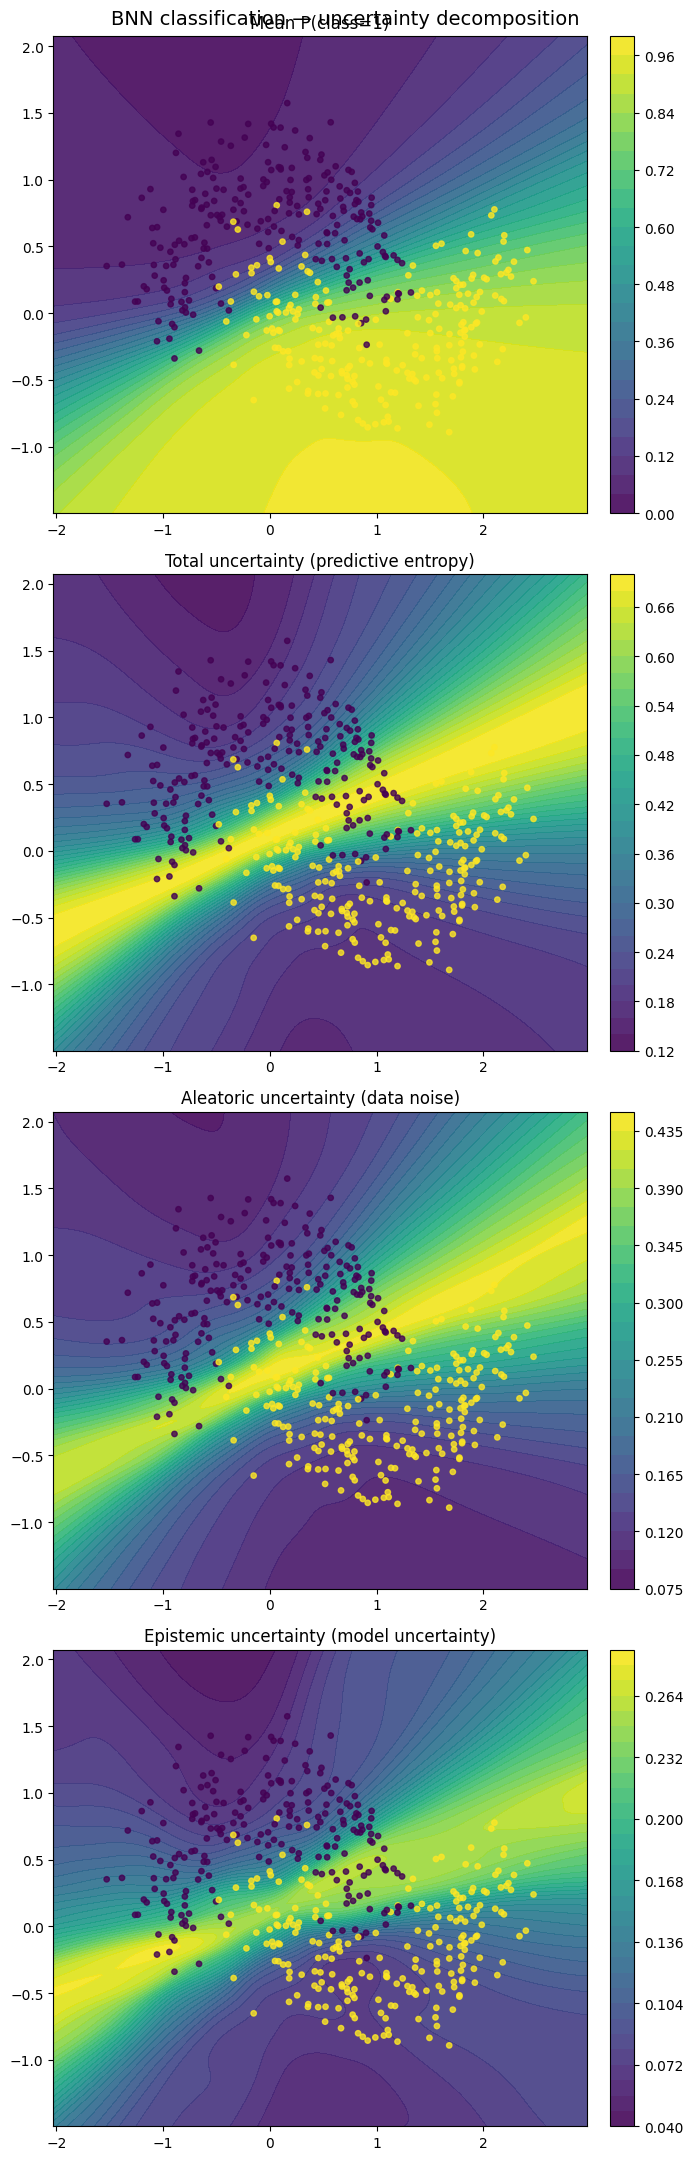

In [18]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

set_seed(2)

X, y = make_moons(n_samples=600, noise=0.25, random_state=0)
X = X.astype(np.float32)
y = y.astype(np.int64)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

X_train_t = torch.from_numpy(X_train_np).to(device)
y_train_t = torch.from_numpy(y_train_np).to(device)

X_test_t = torch.from_numpy(X_test_np).to(device)
y_test_t = torch.from_numpy(y_test_np).to(device)

train_loader_cls = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=128,
    shuffle=True,
)

class BayesianClassifier(nn.Module):
    def __init__(self, hidden: int = 64, prior_sigma: float = 1.0):
        super().__init__()
        self.l1 = VariationalLinear(2, hidden, prior_sigma=prior_sigma)
        self.l2 = VariationalLinear(hidden, hidden, prior_sigma=prior_sigma)
        self.l3 = VariationalLinear(hidden, 2, prior_sigma=prior_sigma)

    def forward(self, x):
        x = torch.tanh(self.l1(x))
        x = torch.tanh(self.l2(x))
        logits = self.l3(x)
        return logits

    def kl_loss(self):
        return self.l1.kl_divergence() + self.l2.kl_divergence() + self.l3.kl_divergence()

bnn_cls = BayesianClassifier(hidden=64, prior_sigma=1.0).to(device)
opt = torch.optim.Adam(bnn_cls.parameters(), lr=1e-3)

epochs = 2000
N = len(X_train_t)

bnn_cls.train()
for epoch in range(1, epochs + 1):
    beta = min(1.0, epoch / 500.0)

    for xb, yb in train_loader_cls:
        logits = bnn_cls(xb)     # weights sampled internally
        nll = F.cross_entropy(logits, yb)   # mean NLL
        kl = bnn_cls.kl_loss()
        loss = nll + beta * kl / N

        opt.zero_grad()
        loss.backward()
        opt.step()

    if epoch % 400 == 0:
        with torch.no_grad():
            bnn_cls.eval()
            # quick 1-sample accuracy estimate (for a proper Bayesian accuracy, sample multiple)
            logits_test = bnn_cls(X_test_t)
            acc = (logits_test.argmax(dim=1) == y_test_t).float().mean().item()
            bnn_cls.train()
        print(f"[BNN cls] epoch={epoch:4d}  nll={nll.item():.4f}  acc(one-sample)={acc:.3f}")

# Create a grid for visualization
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200, dtype=np.float32),
    np.linspace(y_min, y_max, 200, dtype=np.float32),
)
grid = np.stack([xx.ravel(), yy.ravel()], axis=1)
grid_t = torch.from_numpy(grid).to(device)

# MC predictive probabilities
bnn_cls.eval()
S = 100
with torch.no_grad():
    probs = []
    for _ in range(S):
        logits = bnn_cls(grid_t)
        probs.append(F.softmax(logits, dim=1).cpu().numpy())
    probs = np.stack(probs, axis=0)  # [S, n_grid, 2]

p_mean = probs.mean(axis=0)  # [n_grid, 2]
p1 = p_mean[:, 1].reshape(xx.shape)

eps = 1e-9

# Total uncertainty  = H[E_w p(y|x,w)]  (entropy of the mean prediction)
total = -(p_mean * np.log(p_mean + eps)).sum(axis=1).reshape(xx.shape)

# Aleatoric uncertainty = E_w[H[p(y|x,w)]]  (mean entropy of individual samples)
per_sample_entropy = -(probs * np.log(probs + eps)).sum(axis=2)  # [S, n_grid]
aleatoric = per_sample_entropy.mean(axis=0).reshape(xx.shape)

# Epistemic uncertainty = Total - Aleatoric  (mutual information I(y;w|x))
epistemic = total - aleatoric

fig, axes = plt.subplots(4, 1, figsize=(7, 22))

im0 = axes[0].contourf(xx, yy, p1, levels=30, alpha=0.9)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, s=15, alpha=0.8)
axes[0].set_title("Mean P(class=1)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].contourf(xx, yy, total, levels=30, alpha=0.9)
axes[1].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, s=15, alpha=0.8)
axes[1].set_title("Total uncertainty (predictive entropy)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].contourf(xx, yy, aleatoric, levels=30, alpha=0.9)
axes[2].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, s=15, alpha=0.8)
axes[2].set_title("Aleatoric uncertainty (data noise)")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].contourf(xx, yy, epistemic, levels=30, alpha=0.9)
axes[3].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, s=15, alpha=0.8)
axes[3].set_title("Epistemic uncertainty (model uncertainty)")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

fig.suptitle("BNN classification — uncertainty decomposition", fontsize=14)
plt.tight_layout()
plt.show()


## Exercises

1. **Prior sensitivity**  
   Change `prior_sigma` (e.g., 0.1, 0.5, 1.0, 2.0).  
   How do the fit and uncertainty bands change?

2. **KL annealing**  
   Remove the warm-up (`beta=1.0` from the start).  
   Does optimization get harder? Why?

3. **Number of MC samples**  
   Try `S=20` vs `S=500` at prediction time.  
   How stable are the uncertainty bands / entropy plots?


## Further reading (references)

- Blundell et al., **Weight Uncertainty in Neural Networks** (Bayes by Backprop)
- Neal, **Bayesian Learning for Neural Networks** (classic)
- Gal & Ghahramani, **Dropout as a Bayesian Approximation**
- MacKay, **Information Theory, Inference, and Learning Algorithms** (Bayesian ML foundations)
- Bishop, **Pattern Recognition and Machine Learning** (VI basics)
